In [16]:
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error

print("TensorFlow Version:", tf.__version__)

TensorFlow Version: 2.20.0


Sythetic EV Battery DataSet

> Add blockquote



In [17]:
import numpy as np
import matplotlib.pyplot as plt

# Domain
L = 1.0
T = 1.0

nx = 201
nt = 201

x = np.linspace(0, L, nx)
t = np.linspace(0, T, nt)

X, T_mesh = np.meshgrid(x, t)

nu = 0.05

# Analytical airflow profile
U = 4.0 + np.exp(-nu*np.pi**2*T_mesh) * np.sin(np.pi*X)

print("Dataset generated.")

Dataset generated.


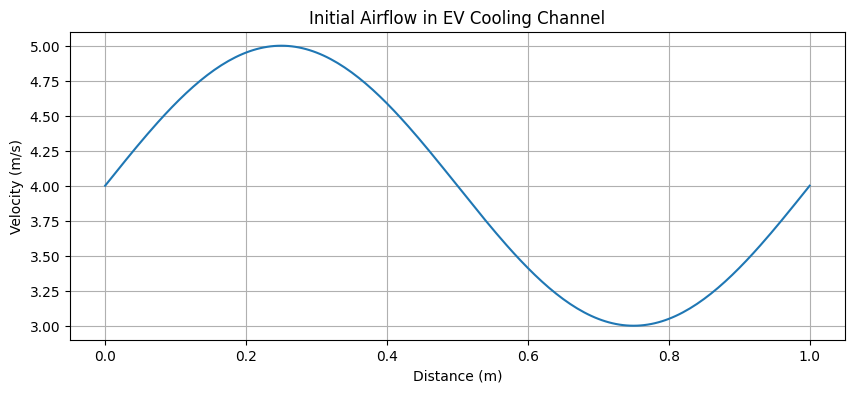

In [18]:
U = np.zeros((nt, nx))

# Initial airflow profile
U[0, :] = 4 + np.sin(2*np.pi*x)

plt.figure(figsize=(10,4))
plt.plot(x, U[0])
plt.xlabel("Distance (m)")
plt.ylabel("Velocity (m/s)")
plt.title("Initial Airflow in EV Cooling Channel")
plt.grid(True)
plt.show()

Solve Burgers' Equation

In [21]:
L = 1.0
T = 1.0

nx = 201
nt = 201

x = np.linspace(0, L, nx)
t = np.linspace(0, T, nt)

X, T_mesh = np.meshgrid(x, t)

nu = 0.05

U = 4.0 + np.exp(-nu * np.pi**2 * T_mesh) * np.sin(np.pi * X)

Generate Dataset

In [22]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

L = 1.0
T = 1.0

nx = 201
nt = 201

x = np.linspace(0, L, nx)
t = np.linspace(0, T, nt)

X, T_mesh = np.meshgrid(x, t)

nu = 0.05

U = 4 + np.exp(-nu*np.pi**2*T_mesh)*np.sin(np.pi*X)

print("NaN :", np.isnan(U).sum())
print("Inf :", np.isinf(U).sum())

NaN : 0
Inf : 0


Visualize Dataset

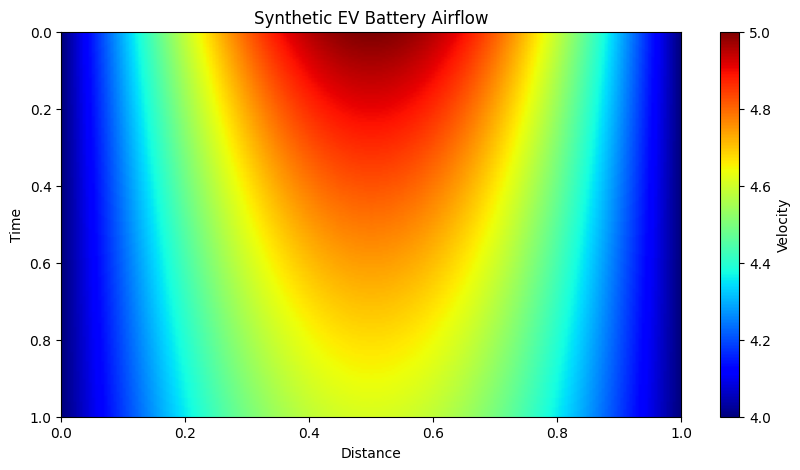

In [23]:
plt.figure(figsize=(10,5))

plt.imshow(
    U,
    extent=[0,1,1,0],
    aspect="auto",
    cmap="jet"
)

plt.colorbar(label="Velocity")

plt.xlabel("Distance")

plt.ylabel("Time")

plt.title("Synthetic EV Battery Airflow")

plt.show()

Create Dataset

In [24]:
dataset = pd.DataFrame({

    "x": X.flatten(),

    "t": T_mesh.flatten(),

    "velocity": U.flatten()

})

dataset.head()

,x,t,velocity
0,0.000,0.0,4.000000
1,0.005,0.0,4.015707
2,0.010,0.0,4.031411
3,0.015,0.0,4.047106
4,0.020,0.0,4.062791


Split Dataset

In [25]:
from sklearn.model_selection import train_test_split

train, temp = train_test_split(
    dataset,
    test_size=0.2,
    random_state=42
)

val, test = train_test_split(
    temp,
    test_size=0.5,
    random_state=42
)

print(train.shape)
print(val.shape)
print(test.shape)

(32320, 3)
(4040, 3)
(4041, 3)


In [26]:
train.to_csv("train.csv",index=False)
val.to_csv("val.csv",index=False)
test.to_csv("test.csv",index=False)

print("CSV Files Saved")

CSV Files Saved


Load Dataset

In [27]:
train = pd.read_csv("train.csv")
val = pd.read_csv("val.csv")
test = pd.read_csv("test.csv")

print(train.head())

       x      t  velocity
0  0.650  0.970  4.552071
1  0.845  0.615  4.345443
2  0.995  0.660  4.011341
3  0.815  0.770  4.375463
4  0.395  0.900  4.606801


Prepare Data

In [28]:
from sklearn.preprocessing import MinMaxScaler

x_scaler = MinMaxScaler()
y_scaler = MinMaxScaler()

X_train = train[["x","t"]].values
y_train = train[["velocity"]].values

X_val = val[["x","t"]].values
y_val = val[["velocity"]].values

X_test = test[["x","t"]].values
y_test = test[["velocity"]].values

X_train = x_scaler.fit_transform(X_train)
X_val = x_scaler.transform(X_val)
X_test = x_scaler.transform(X_test)

y_train = y_scaler.fit_transform(y_train)
y_val = y_scaler.transform(y_val)
y_test = y_scaler.transform(y_test)

print("Normalization Completed")

Normalization Completed


TensorFlow

In [29]:
import tensorflow as tf

x_train_tf = tf.convert_to_tensor(X_train[:,0:1],dtype=tf.float32)
t_train_tf = tf.convert_to_tensor(X_train[:,1:2],dtype=tf.float32)
u_train_tf = tf.convert_to_tensor(y_train,dtype=tf.float32)

print(x_train_tf.shape)

(32320, 1)


Collocation Points

In [30]:
N_f = 10000

x_f = tf.random.uniform((N_f,1),0,1,dtype=tf.float32)
t_f = tf.random.uniform((N_f,1),0,1,dtype=tf.float32)

print(x_f.shape)

(10000, 1)


PINN Network

In [31]:
class PINN(tf.keras.Model):

    def __init__(self):
        super().__init__()

        self.d1 = tf.keras.layers.Dense(64,activation="tanh")
        self.d2 = tf.keras.layers.Dense(64,activation="tanh")
        self.d3 = tf.keras.layers.Dense(64,activation="tanh")
        self.d4 = tf.keras.layers.Dense(64,activation="tanh")

        self.out = tf.keras.layers.Dense(1)

    def call(self,x):

        x = self.d1(x)
        x = self.d2(x)
        x = self.d3(x)
        x = self.d4(x)

        return self.out(x)

model = PINN()

print(model(tf.random.normal((5,2))))

tf.Tensor(
[[ 0.02419171]
 [ 0.04592931]
 [-0.00694589]
 [-0.10267405]
 [-0.00358435]], shape=(5, 1), dtype=float32)


Burgers' Physics Residual

In [32]:
nu = 0.05

def burgers_residual(model, x, t):

    with tf.GradientTape(persistent=True) as tape2:

        tape2.watch([x, t])

        with tf.GradientTape(persistent=True) as tape1:

            tape1.watch([x, t])

            XT = tf.concat([x, t], axis=1)

            u = model(XT)

        u_x = tape1.gradient(u, x)
        u_t = tape1.gradient(u, t)

    u_xx = tape2.gradient(u_x, x)

    del tape1
    del tape2

    residual = u_t + u*u_x - nu*u_xx

    return residual

Physics Loss

In [33]:
def physics_loss(model, x, t):

    f = burgers_residual(model, x, t)

    return tf.reduce_mean(tf.square(f))

Data Loss

In [34]:
def data_loss(model, x, t, u_true):

    XT = tf.concat([x, t], axis=1)

    u_pred = model(XT)

    return tf.reduce_mean(tf.square(u_true-u_pred))

Initial Condition

In [35]:
x0 = tf.linspace(0.0,1.0,201)

x0 = tf.reshape(x0,(-1,1))

t0 = tf.zeros_like(x0)

u0 = 4.0 + tf.sin(np.pi*x0)

Initial Condition Loss

In [36]:
def initial_loss(model):

    XT = tf.concat([x0,t0],axis=1)

    pred = model(XT)

    return tf.reduce_mean(tf.square(pred-u0))

Boundary Condition Loss

In [37]:
tb = tf.linspace(0.0,1.0,201)

tb = tf.reshape(tb,(-1,1))

xl = tf.zeros_like(tb)

xr = tf.ones_like(tb)

ub = 4.0*tf.ones_like(tb)

LOSS

In [38]:
def boundary_loss(model):

    left = model(tf.concat([xl,tb],axis=1))

    right = model(tf.concat([xr,tb],axis=1))

    return (
        tf.reduce_mean(tf.square(left-ub))
        +
        tf.reduce_mean(tf.square(right-ub))
    )

Total PINN Loss

In [39]:
def total_loss(model):

    dl = data_loss(
        model,
        x_train_tf,
        t_train_tf,
        u_train_tf
    )

    pl = physics_loss(
        model,
        x_f,
        t_f
    )

    il = initial_loss(model)

    bl = boundary_loss(model)

    total = dl + pl + il + bl

    return total,dl,pl,il,bl

Optimizer

In [40]:
optimizer = tf.keras.optimizers.Adam(
    learning_rate=0.001
)

One Training Step

In [41]:
@tf.function
def train_step():

    with tf.GradientTape() as tape:

        total,dl,pl,il,bl = total_loss(model)

    gradients = tape.gradient(
        total,
        model.trainable_variables
    )

    optimizer.apply_gradients(
        zip(
            gradients,
            model.trainable_variables
        )
    )

    return total,dl,pl,il,bl

Verify

In [42]:
total, dl, pl, il, bl = total_loss(model)

print("Total Loss    :", total.numpy())
print("Data Loss     :", dl.numpy())
print("Physics Loss  :", pl.numpy())
print("Initial Loss  :", il.numpy())
print("Boundary Loss :", bl.numpy())

Total Loss    : 53.135513
Data Loss     : 0.28300828
Physics Loss  : 0.00077305624
Initial Loss  : 21.36267
Boundary Loss : 31.489063


The above tells that PINN is working correctly being finite numbers (no NaN and no Inf).

Now the below is to TRAIN THE PINN

In [43]:
import time

epochs = 1000

loss_history = []
data_history = []
physics_history = []
initial_history = []
boundary_history = []

start = time.time()

for epoch in range(epochs):

    total, d_loss, p_loss, i_loss, b_loss = train_step()

    loss_history.append(float(total.numpy()))
    data_history.append(float(d_loss.numpy()))
    physics_history.append(float(p_loss.numpy()))
    initial_history.append(float(i_loss.numpy()))
    boundary_history.append(float(b_loss.numpy()))

    if epoch % 100 == 0:

        print(f"Epoch {epoch:4d}/{epochs}")
        print(f" Total Loss    : {total.numpy():.6f}")
        print(f" Data Loss     : {d_loss.numpy():.6f}")
        print(f" Physics Loss  : {p_loss.numpy():.6f}")
        print(f" Initial Loss  : {i_loss.numpy():.6f}")
        print(f" Boundary Loss : {b_loss.numpy():.6f}")
        print("-"*40)

        model.save_weights("EV_Battery_PINN.weights.h5")

end = time.time()

print(f"Training completed in {(end-start)/60:.2f} minutes")

Epoch    0/1000
 Total Loss    : 53.135513
 Data Loss     : 0.283008
 Physics Loss  : 0.000773
 Initial Loss  : 21.362671
 Boundary Loss : 31.489063
----------------------------------------
Epoch  100/1000
 Total Loss    : 9.777474
 Data Loss     : 6.933721
 Physics Loss  : 0.044737
 Initial Loss  : 0.725728
 Boundary Loss : 2.073288
----------------------------------------
Epoch  200/1000
 Total Loss    : 9.529580
 Data Loss     : 6.769654
 Physics Loss  : 0.022509
 Initial Loss  : 0.600939
 Boundary Loss : 2.136477
----------------------------------------
Epoch  300/1000
 Total Loss    : 9.258040
 Data Loss     : 6.558750
 Physics Loss  : 0.028372
 Initial Loss  : 0.493255
 Boundary Loss : 2.177663
----------------------------------------
Epoch  400/1000
 Total Loss    : 9.152053
 Data Loss     : 6.432363
 Physics Loss  : 0.054950
 Initial Loss  : 0.382259
 Boundary Loss : 2.282480
----------------------------------------
Epoch  500/1000
 Total Loss    : 9.110996
 Data Loss     : 6.4

Plot Loss Curves

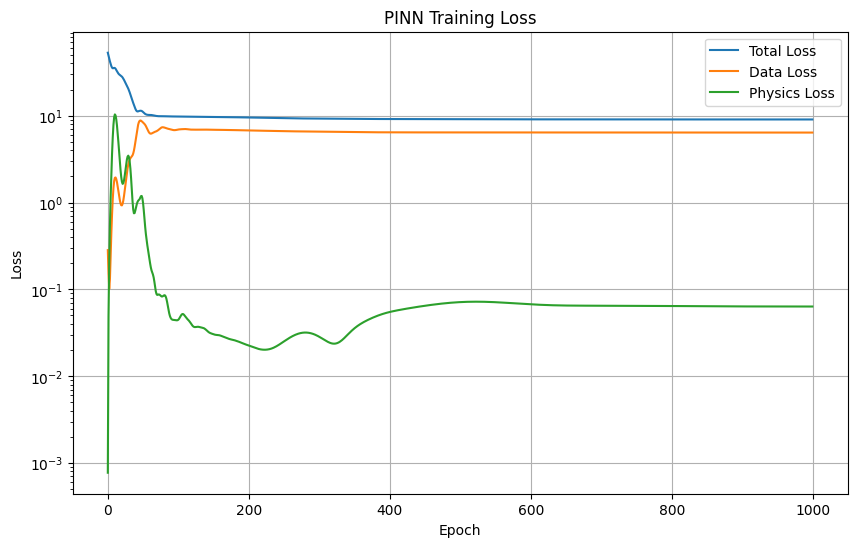

In [44]:
plt.figure(figsize=(10,6))

plt.plot(loss_history, label="Total Loss")
plt.plot(data_history, label="Data Loss")
plt.plot(physics_history, label="Physics Loss")

plt.yscale("log")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("PINN Training Loss")

plt.grid(True)
plt.legend()

plt.show()

In [46]:
# Convert validation data
x_val_tf = tf.convert_to_tensor(X_val[:, 0:1], dtype=tf.float32)
t_val_tf = tf.convert_to_tensor(X_val[:, 1:2], dtype=tf.float32)
u_val_tf = tf.convert_to_tensor(y_val, dtype=tf.float32)

# Convert test data
x_test_tf = tf.convert_to_tensor(X_test[:, 0:1], dtype=tf.float32)
t_test_tf = tf.convert_to_tensor(X_test[:, 1:2], dtype=tf.float32)
u_test_tf = tf.convert_to_tensor(y_test, dtype=tf.float32)

print("Validation and Test tensors created successfully!")
print("x_test_tf shape:", x_test_tf.shape)
print("t_test_tf shape:", t_test_tf.shape)
print("u_test_tf shape:", u_test_tf.shape)

Validation and Test tensors created successfully!
x_test_tf shape: (4041, 1)
t_test_tf shape: (4041, 1)
u_test_tf shape: (4041, 1)


In [47]:
XT_test = tf.concat([x_test_tf, t_test_tf], axis=1)

prediction = model(XT_test)

prediction = prediction.numpy()

prediction = y_scaler.inverse_transform(prediction)

truth = y_scaler.inverse_transform(y_test)

Mean Squared Error (MSE)

In [48]:
from sklearn.metrics import mean_squared_error

mse = mean_squared_error(truth, prediction)

print("PINN Mean Squared Error (MSE):", mse)

PINN Mean Squared Error (MSE): 6.4034967196618355


In [49]:
relative_l2 = np.linalg.norm(truth - prediction) / np.linalg.norm(truth)

print("PINN Relative L2 Error:", relative_l2)

PINN Relative L2 Error: 0.5607059511901471


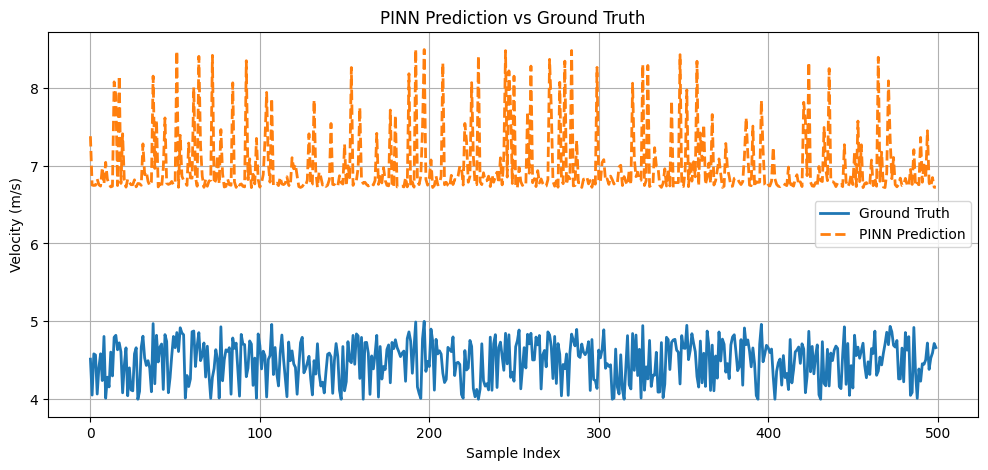

In [50]:
plt.figure(figsize=(12,5))

plt.plot(truth[:500], label="Ground Truth", linewidth=2)
plt.plot(prediction[:500], '--', label="PINN Prediction", linewidth=2)

plt.xlabel("Sample Index")
plt.ylabel("Velocity (m/s)")
plt.title("PINN Prediction vs Ground Truth")

plt.legend()
plt.grid(True)

plt.show()

In [51]:
XT_all = np.column_stack((X.flatten(), T_mesh.flatten()))

XT_all_scaled = x_scaler.transform(XT_all)

XT_all_tf = tf.convert_to_tensor(XT_all_scaled, dtype=tf.float32)

pred_all = model(XT_all_tf)

pred_all = pred_all.numpy()

pred_all = y_scaler.inverse_transform(pred_all)

pred_grid = pred_all.reshape(201,201)

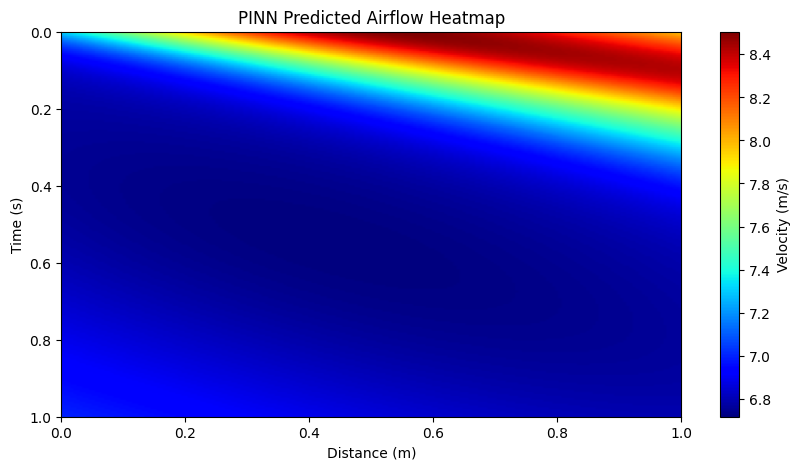

In [52]:
plt.figure(figsize=(10,5))

plt.imshow(
    pred_grid,
    extent=[0,1,1,0],
    aspect='auto',
    cmap='jet'
)

plt.colorbar(label="Velocity (m/s)")
plt.xlabel("Distance (m)")
plt.ylabel("Time (s)")
plt.title("PINN Predicted Airflow Heatmap")

plt.show()

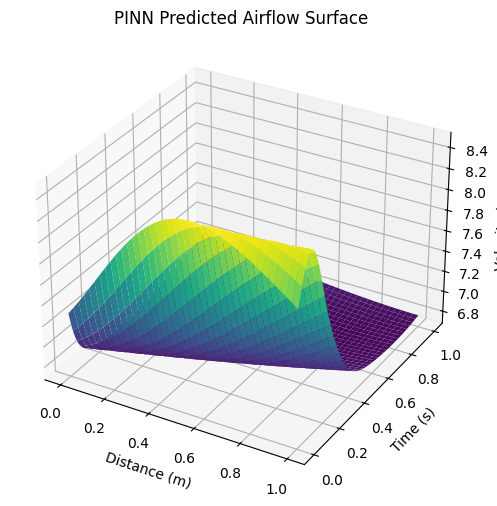

In [53]:
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(10,6))

ax = fig.add_subplot(111, projection='3d')

ax.plot_surface(
    X,
    T_mesh,
    pred_grid,
    cmap='viridis',
    edgecolor='none'
)

ax.set_xlabel("Distance (m)")
ax.set_ylabel("Time (s)")
ax.set_zlabel("Velocity (m/s)")
ax.set_title("PINN Predicted Airflow Surface")

plt.show()

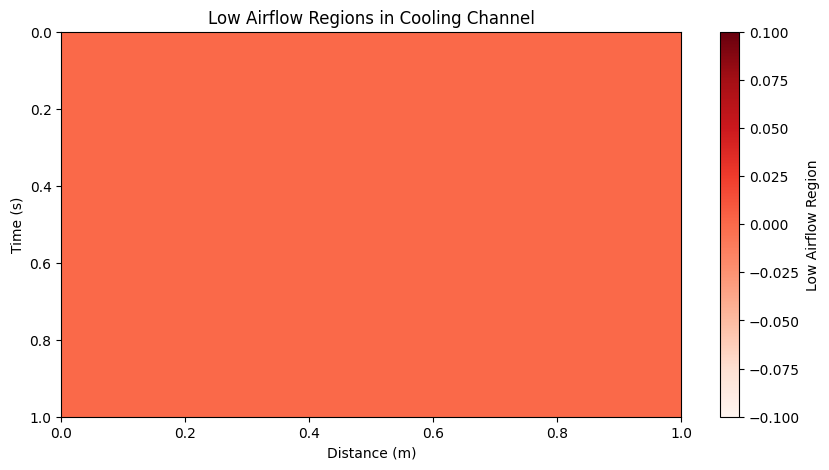

In [54]:
threshold = 4.2

congested = pred_grid < threshold

plt.figure(figsize=(10,5))

plt.imshow(
    congested,
    extent=[0,1,1,0],
    aspect='auto',
    cmap='Reds'
)

plt.colorbar(label="Low Airflow Region")

plt.xlabel("Distance (m)")
plt.ylabel("Time (s)")
plt.title("Low Airflow Regions in Cooling Channel")

plt.show()

In [55]:
model.save_weights("EV_Battery_PINN.weights.h5")

print("PINN model saved successfully!")

PINN model saved successfully!
